# **RQ 3**: DO the anglicisms tend to be central?


## **1st approach**

Two measures are computed in order to investigate this phenomenon:

1. *PageRank*, to compute the semantic centrality of the word;
2. *Participation Coefficient*, to compute the cross-community connectivity. If the node is near 0, it talks only with its community; otherwise, it connects more communities

In [2]:
import igraph as ig
import pandas as pd
import numpy as np
import os
from pathlib import Path
import nltk
from nltk.corpus import words as nltk_words
import matplotlib.pyplot as plt

Anglicisms detector & Partecipation Coefficient

In [3]:
# --- 1. SETUP RILEVATORE ANGLISMI ---
print("Configurazione rilevatore Anglismi...")

# A. Dizionario Inglese
nltk.download('words')
english_vocab = set(w.lower() for w in nltk_words.words())

# B. Dizionario Italiano (NVdB) che hai già caricato prima
try:
    nvdb = pd.read_csv('nvdb.csv').set_index('lemma')['categoria'].to_dict()
    italian_vocab = set(nvdb.keys())
except:
    print("NVdB non trovato, userò solo euristiche (meno preciso).")
    italian_vocab = set()

# C. Lista Manuale di "Falsi Amici" (Parole uguali in IT/EN da NON contare come anglismi)
false_friends = {
    "area", "data", "media", "camera", "fine", "fame", "mare", "male", 
    "sale", "note", "base", "piano", "zero", "uno", "due", "no", "si", 
    "latina", "arena", "vision", "mission", "radio", "video", "virus", 
    "agenda", "alibi", "atlas", "bonus", "campus", "cinema", "item", "tram", "bar"
}

def is_anglicism(word):
    """Restituisce True se la parola è probabilmente un anglismo recente"""
    if len(word) < 3: return False
    if word in false_friends: return False
    
    # Se è nel dizionario italiano, NON è un anglismo (escludiamo prestiti storici consolidati)
    if word in italian_vocab: return False
    
    # Se è nel dizionario inglese
    if word in english_vocab:
        return True
        
    return False

# --- 2. FUNZIONE PARTECIPATION COEFFICIENT ---
def calculate_participation(G, clustering):
    """
    Calcola il Participation Coefficient (P) per ogni nodo.
    P misura quanto uniformemente un nodo distribuisce i suoi link tra le comunità.
    """
    # Membership list: a quale comunità appartiene ogni nodo
    membership = clustering.membership
    num_communities = len(clustering)
    
    # Grado totale di ogni nodo
    degrees = np.array(G.degree())
    
    # Preparare struttura per contare link intra-community
    # participation = 1 - sum((kis / ki)^2)
    
    participation_scores = []
    
    for v_idx, v in enumerate(G.vs):
        k_i = degrees[v_idx]
        if k_i == 0:
            participation_scores.append(0.0)
            continue
            
        # Ottieni vicini
        neighbors = G.neighbors(v)
        
        # Conta quanti vicini sono in ciascuna comunità
        community_counts = {}
        for neighbor in neighbors:
            comm_id = membership[neighbor]
            community_counts[comm_id] = community_counts.get(comm_id, 0) + 1
            
        # Calcolo somma dei quadrati delle frazioni
        sum_sq = 0.0
        for count in community_counts.values():
            ratio = count / k_i
            sum_sq += ratio * ratio
            
        p_i = 1 - sum_sq
        participation_scores.append(p_i)
        
    return participation_scores


Configurazione rilevatore Anglismi...


[nltk_data] Downloading package words to
[nltk_data]     C:\Users\leona\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-to-date!


In [4]:
# --- 3. ANALISI LONGITUDINALE ---
input_dir = Path("networks_annotated") # Usa i file annotati o quelli base
files = sorted([f for f in os.listdir(input_dir) if "snap" in f], 
               key=lambda x: int(x.split("_")[1].replace("snap", "")))

rq3_results = []

def is_complex_italian(word, level):
        """Restituisce True se la parola è una parola italiana 'complesse' (non banale). Se la parola non è nel dizionario italiano, restituisce False."""
        if level == 3:  # Livello 'Altro' (non banale)
            return True
        return False

print("Inizio analisi RQ3 (Anglismi)...")

for file in files:
    try:
        year = int(file.split("_")[1].replace("snap", ""))
    except: continue
        
    print(f"Processing {year}...", end="")
    
    # Carica Grafo
    path = input_dir / file
    G = ig.Graph.Read_Pickle(str(path))
    
    if G.vcount() == 0: continue

    # 1. Rilevamento Anglismi
    # (Potresti salvarlo come attributo del nodo per non rifarlo)
    node_names = G.vs['token']
    is_anglo_mask = [is_anglicism(w) for w in node_names]
    Demauro_level = G.vs['demauro_level'] # Livello Demauro per ogni parola
    is_complex_mask = [is_complex_italian(w, l) for w, l in zip(node_names, Demauro_level)]
    
    # Converti in array booleano per filtraggio facile
    is_anglo_arr = np.array(is_anglo_mask)
    num_anglo = np.sum(is_anglo_arr)
    
    if num_anglo == 0:
        print(f" Nessun anglismo trovato (strano).")
        continue

    # 2. Calcolo Centralità (PageRank)
    pagerank = np.array(G.pagerank(weights='weight'))
    # Normalizza PageRank per confrontare anni diversi (somma=1, ma meglio *N)
    # pagerank_norm = pagerank * G.vcount() 
    
    # 3. Calcolo Comunità e Participation Coefficient
    # Usiamo Leiden (più veloce/stabile di Louvain)
    clusters = G.community_leiden(objective_function="modularity", weights='weight')
    participation = np.array(calculate_participation(G, clusters))
    
    # 4. Aggregazione Dati (Anglismi vs Italiani)
    
    # Gruppo Anglismi
    pr_anglo = np.mean(pagerank[is_anglo_arr])
    part_anglo = np.mean(participation[is_anglo_arr])
    
    # Gruppo Italiani (Non-Anglismi ma Parole Complesse)
    pr_it = np.mean(pagerank[~is_anglo_arr & is_complex_mask])
    part_it = np.mean(participation[~is_anglo_arr & is_complex_mask])
    
    # Top 5 Anglismi per importanza (Controllo qualità)
    # Prendiamo gli indici degli anglismi, ordiniamo per pagerank
    anglo_indices = np.where(is_anglo_arr)[0]
    top_anglo_idx = anglo_indices[np.argsort(pagerank[anglo_indices])[-5:]]
    top_anglo_words = [node_names[i] for i in top_anglo_idx]
    
    rq3_results.append({
        "year": year,
        "num_anglicisms": num_anglo,
        "perc_vocab_anglo": num_anglo / G.vcount(),
        
        # Centralità
        "avg_pagerank_anglo": pr_anglo,
        "avg_pagerank_italian": pr_it,
        "ratio_centrality": pr_anglo / pr_it, # Se > 1, gli anglismi sono più centrali della media
        
        # Connettività Cross-Community
        "avg_participation_anglo": part_anglo,
        "avg_participation_italian": part_it,
        "ratio_participation": part_anglo / part_it, # Se > 1, gli anglismi connettono più comunità
        
        "top_anglicisms": ", ".join(top_anglo_words)
    })
    
    print(" Fatto.")

df_rq3 = pd.DataFrame(rq3_results)

Inizio analisi RQ3 (Anglismi)...
Processing 1... Fatto.
Processing 2... Fatto.
Processing 3... Fatto.
Processing 4... Fatto.
Processing 5... Fatto.
Processing 6... Fatto.
Processing 7... Fatto.
Processing 8... Fatto.
Processing 9... Fatto.
Processing 10... Fatto.


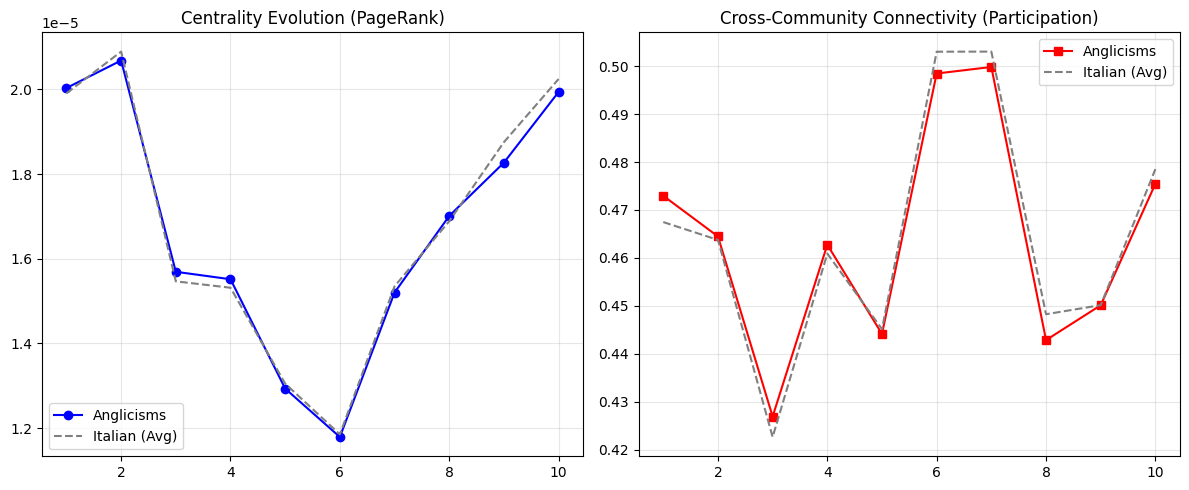

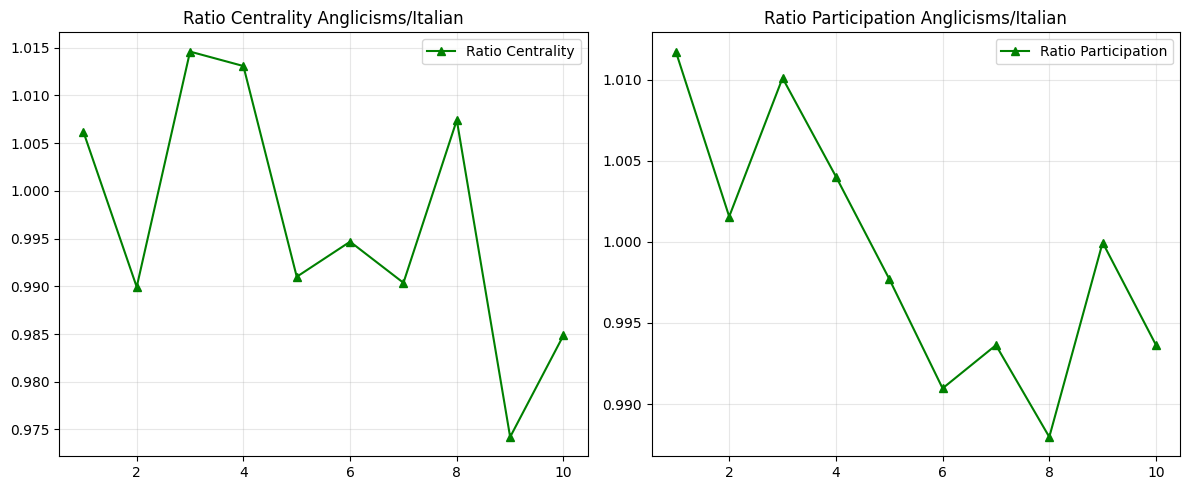

In [7]:
# --- VISUALIZZAZIONE ---

plt.figure(figsize=(12, 5))

# Plot 1: Trend Centralità
plt.subplot(1, 2, 1)
plt.plot(df_rq3['year'], df_rq3['avg_pagerank_anglo'], label='Anglicisms', color='blue', marker='o')
plt.plot(df_rq3['year'], df_rq3['avg_pagerank_italian'], label='Italian (Avg)', color='grey', linestyle='--')
plt.title("Centrality Evolution (PageRank)")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Trend Participation (Cross-Community)
plt.subplot(1, 2, 2)
plt.plot(df_rq3['year'], df_rq3['avg_participation_anglo'], label='Anglicisms', color='red', marker='s')
plt.plot(df_rq3['year'], df_rq3['avg_participation_italian'], label='Italian (Avg)', color='grey', linestyle='--')
plt.title("Cross-Community Connectivity (Participation)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 3: ratio centrality
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(df_rq3['year'], df_rq3['ratio_centrality'], label='Ratio Centrality', color='green', marker='^')
plt.title("Ratio Centrality Anglicisms/Italian")
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 4: ratio participation
plt.subplot(1, 2, 2)
plt.plot(df_rq3['year'], df_rq3['ratio_participation'], label='Ratio Participation', color='green', marker='^')
plt.title("Ratio Participation Anglicisms/Italian")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2nd approach
The control group changes from all the vocabulary to the complex words (i.e., those not present in De Mauro's vocabulary of use). Then, 2 measures are computed:
1. Within-module degree z-score (***z***): how much the node is important inside its community;
2. Participation Coefficient (***P***): how much the node connects different communities.


In [ ]:
# --- FUNZIONI DI SUPPORTO ---
# 1. z-score within module
def calculate_within_module_z_score(G, clustering, weights='weight'):
    """
    Calcola lo z-score del grado interno alla comunità.
    z_i = (k_i - k_avg_s) / sigma_k_s
    Dove k_i è il grado interno del nodo i nella sua comunità s,
    k_avg_s e sigma_k_s sono media e dev. std dei gradi interni nella comunità s.
    """
    membership = np.array(clustering.membership)
    num_comm = len(clustering)
    
    # 1. Calcola il grado interno per ogni nodo (Weighted)
    # Purtroppo igraph non ha una funzione nativa per "grado verso un sottoinsieme", 
    # dobbiamo iterare sugli archi o usare sottografi. 
    # Metodo veloce con matrice di adiacenza sparsa se possibile, o iterazione ottimizzata.
    
    # Per velocità su 50k nodi, usiamo un approccio basato sugli archi
    internal_degrees = np.zeros(G.vcount())
    
    # Iteriamo sugli archi (più veloce che sui nodi per calcolare k_internal)
    for e in G.es:
        u, v = e.source, e.target
        w = e[weights] if weights else 1
        if membership[u] == membership[v]:
            internal_degrees[u] += w
            internal_degrees[v] += w
            
    # 2. Calcola media e std per ogni comunità
    z_scores = np.zeros(G.vcount())
    
    for c in range(num_comm):
        # Indici dei nodi nella comunità c
        nodes_in_c = np.where(membership == c)[0]
        
        if len(nodes_in_c) < 2:
            z_scores[nodes_in_c] = 0
            continue
            
        k_vals = internal_degrees[nodes_in_c]
        mean_k = np.mean(k_vals)
        std_k = np.std(k_vals)
        
        if std_k == 0:
            z_scores[nodes_in_c] = 0
        else:
            z_scores[nodes_in_c] = (k_vals - mean_k) / std_k
            
    return z_scores

# 2. Participation Coefficient

def calculate_participation(G, clustering):
    membership = clustering.membership
    degrees = np.array(G.degree())
    participation_scores = []
    for v_idx, v in enumerate(G.vs):
        k_i = degrees[v_idx]
        if k_i == 0:
            participation_scores.append(0.0)
            continue
        neighbors = G.neighbors(v)
        community_counts = {}
        for neighbor in neighbors:
            comm_id = membership[neighbor]
            community_counts[comm_id] = community_counts.get(comm_id, 0) + 1
        sum_sq = sum((count / k_i)**2 for count in community_counts.values())
        participation_scores.append(1 - sum_sq)
    return np.array(participation_scores)


### Leiden Communities

In [ ]:

# --- ANALISI ---

input_dir = Path("networks_annotated") 
files = sorted([f for f in os.listdir(input_dir) if "snap" in f], 
               key=lambda x: int(x.split("_")[1].replace("snap", "")))

rq3_advanced = []

print("Inizio analisi avanzata RQ3 (Cartografia z-P)...")

for file in files:
    try:
        year = int(file.split("_")[1].replace("snap", ""))
    except: continue
        
    print(f"Analisi {year}...", end="")
    
    path = input_dir / file
    G = ig.Graph.Read_Pickle(str(path))
    
    # 1. Identificazione Gruppi
    # Recuperiamo gli attributi se li hai salvati, o ricalcoliamo al volo
    node_names = G.vs['token']
    
    # MASK ANGLISMI (Usa la tua funzione is_anglicism definita prima)
    is_anglo = np.array([is_anglicism(w) for w in node_names])
    
    # MASK CONTROLLO: Parole Italiane COMPLESSE (De Mauro 'Altro' o IDF alto)
    # Escludiamo le parole comuni (FO/AU) per un confronto equo
    if 'demauro_level' in G.vs.attributes():
        dm_levels = np.array(G.vs['demauro_level'])
        # 0=FO, 1=AU, 2=AD, 3=Altro. 
        # Confrontiamo con parole "semanticamente dense" (livello 3)
        mask_control = (dm_levels == 3) & (~is_anglo)
    else:
        # Fallback se non hai attributi: usa tutte le non-anglo
        mask_control = ~is_anglo

    # 2. Calcolo Comunità (Leiden)
    clusters = G.community_leiden(objective_function="modularity", weights='weight')
    
    # 3. Calcolo Metriche Cartografiche (z-score e P)
    z_scores = calculate_within_module_z_score(G, clusters, weights='weight')
    participation = calculate_participation(G, clusters)

    # 5. Aggregazione
    
    # Anglismi
    anglo_z = np.mean(z_scores[is_anglo])
    anglo_p = np.mean(participation[is_anglo])
    
    # Controllo (Italiano Complesso)
    ctrl_z = np.mean(z_scores[mask_control])
    ctrl_p = np.mean(participation[mask_control])
    
    # Classificazione Ruoli (Guimerà-Amaral)
    # R3: Non-hub connector (z < 2.5, P > 0.62) -> Il vero "Ponte"
    # R6: Connector Hub (z > 2.5, P > 0.62) -> Leader globale
    
    # Contiamo quanti anglismi sono "Connettori" (P > 0.62 è la soglia teorica, ma 0.5 è pratica)
    threshold_P = 0.5 
    num_anglo_connectors = np.sum((participation[is_anglo] > threshold_P))
    perc_anglo_connectors = num_anglo_connectors / np.sum(is_anglo) if np.sum(is_anglo) > 0 else 0
    
    num_ctrl_connectors = np.sum((participation[mask_control] > threshold_P))
    perc_ctrl_connectors = num_ctrl_connectors / np.sum(mask_control) if np.sum(mask_control) > 0 else 0

    rq3_advanced.append({
        "year": year,
        "z_anglo": anglo_z,
        "z_control": ctrl_z,
        "p_anglo": anglo_p,
        "p_control": ctrl_p,
        "gap_participation": anglo_p - ctrl_p, # Se > 0, anglismi più cosmopoliti
        "perc_anglo_connectors": perc_anglo_connectors,
        "perc_control_connectors": perc_ctrl_connectors
    })
    
    print(" Fatto.")
df_adv = pd.DataFrame(rq3_advanced)
print(df_adv.head())

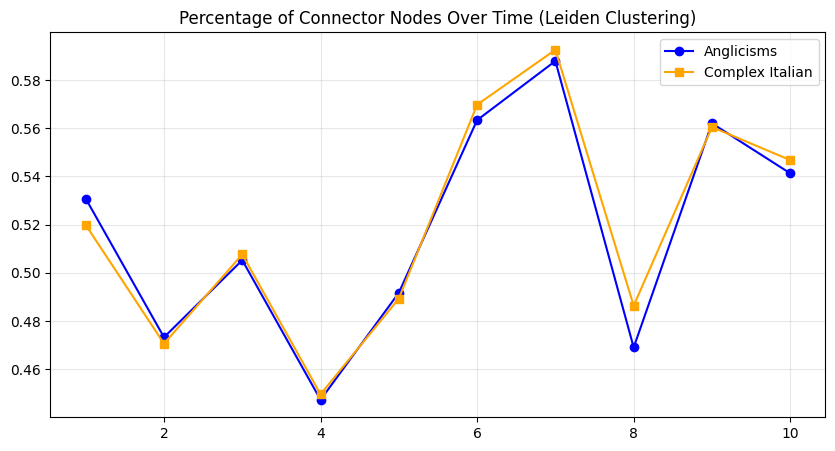

In [ ]:
# plot percentage of connectors anglisms vs control over time
plt.figure(figsize=(10, 5))
plt.plot(df_adv['year'], df_adv['perc_anglo_connectors'], label='Anglicisms', color='blue', marker='o')
plt.plot(df_adv['year'], df_adv['perc_control_connectors'], label='Complex Italian', color='orange', marker='s')
plt.title("Percentage of Connector Nodes Over Time (Leiden Clustering)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Infomap communities

In [ ]:
# --- ANALISI ---

input_dir = Path("networks_annotated") 
files = sorted([f for f in os.listdir(input_dir) if "snap" in f], 
               key=lambda x: int(x.split("_")[1].replace("snap", "")))

rq3_infomap = []

print("Inizio analisi RQ3 con INFOMAP...")

for file in files:
    try:
        year = int(file.split("_")[1].replace("snap", ""))
    except: continue
        
    print(f"Processing {year}...", end="")
    path = input_dir / file
    G = ig.Graph.Read_Pickle(str(path))
    
    # 1. Filtri (Anglismi vs Controllo)
    node_names = G.vs['token'] # Nomi dei nodi
    is_anglo = np.array([is_anglicism(w) for w in node_names]) # Etichetta gli anglismi
    
    # Controllo: Italiane non banali (De Mauro != 0)
    if 'demauro_level' in G.vs.attributes():
        dm = np.array(G.vs['demauro_level']) # Livello De Mauro
        mask_control = (dm == 3) & (~is_anglo) # Livello 'Altro' (non anglismi)
    else:
        mask_control = ~is_anglo

    # 2. COMMUNITY DETECTION: INFOMAP
    # edge_weights: usa i pesi per guidare il random walker (similarità alta = prob. alta di passaggio)
    # trials: numero di tentativi per evitare minimi locali (default 10 è ok, mettine meno se è lento)
    infomap_clusters = G.community_infomap(edge_weights='weight', trials=5)

    print(f" [Comunità trovate: {len(infomap_clusters)}] ", end="")

    # 3. Metriche Cartografiche (z-P)
    # Ricalcoliamo z e P basandoci sulla partizione Infomap
    z_scores = calculate_within_module_z_score(G, infomap_clusters) # z-score: quanto un nodo è "centrale" nella sua comunità
    participation = calculate_participation(G, infomap_clusters) # P: quanto un nodo connette diverse comunità

    # Vogliamo considerare solo i nodi che abitano in comunità "significative"
    sizes = infomap_clusters.sizes()
    small_comm_ids = {i for i, size in enumerate(sizes) if size < 50}

    # Identifichiamo i nodi che appartengono a comunità piccole
    membership = infomap_clusters.membership
    # Maschera booleana: True se il nodo è in una comunità "VALIDA" (>= 50)
    is_in_big_comm = np.array([m not in small_comm_ids for m in membership])

    mask_anglo_valid = is_anglo & is_in_big_comm
    mask_control_valid = mask_control & is_in_big_comm

    # 4. Aggregazione
    anglo_p = np.mean(participation[mask_anglo_valid]) if np.sum(mask_anglo_valid) > 0 else 0 # media di P per anglismi in comunità grandi
    ctrl_p = np.mean(participation[mask_control_valid]) if np.sum(mask_control_valid) > 0 else 0 # media di P per controllo in comunità grandi
    
    # Percentuale Connettori (P > 0.5 o 0.6)
    thr = 0.5
    perc_anglo_conn = np.mean(participation[mask_anglo_valid] > thr) if np.sum(mask_anglo_valid) > 0 else 0
    perc_ctrl_conn = np.mean(participation[mask_control_valid] > thr) if np.sum(mask_control_valid) > 0 else 0

    rq3_infomap.append({
        "year": year,
        "p_anglo": anglo_p, # Partecipation medio degli anglismi. Se > 0.5, anglismi sono connettori
        "p_control": ctrl_p, # Partecipation medio del controllo. Se > 0.5, controllo sono connettori
        "z_anglo": np.mean(z_scores[mask_anglo_valid]) if np.sum(mask_anglo_valid) > 0 else 0, # z-score medio degli anglismi
        "z_control": np.mean(z_scores[mask_control_valid]) if np.sum(mask_control_valid) > 0 else 0, # z-score medio del controllo
        "gap_p": anglo_p - ctrl_p, # Se > 0.5, anglismi più cosmopoliti
        "perc_anglo_connectors": perc_anglo_conn, # percentuale anglismi che hanno ruolo di connettori
        "perc_ctrl_connectors": perc_ctrl_conn, # percentuale controllo che hanno ruolo di connettori
        "num_communities": len(infomap_clusters)
    })
    
    print("Fatto.")

df_infomap = pd.DataFrame(rq3_infomap)
print(df_infomap)

Inizio analisi RQ3 con INFOMAP...
Processing 1... [Comunità trovate: 889] Fatto.
Processing 2... [Comunità trovate: 854] Fatto.
Processing 3... [Comunità trovate: 737] Fatto.
Processing 4... [Comunità trovate: 878] Fatto.
Processing 5... [Comunità trovate: 1324] Fatto.
Processing 6... [Comunità trovate: 1754] Fatto.
Processing 7... [Comunità trovate: 1200] Fatto.
Processing 8... [Comunità trovate: 1043] Fatto.
Processing 9... [Comunità trovate: 842] Fatto.
Processing 10... [Comunità trovate: 727] Fatto.
   year   p_anglo  p_control     gap_p  perc_anglo_connectors  \
0     1  0.585675   0.583185  0.002490               0.723316   
1     2  0.549456   0.546776  0.002680               0.663773   
2     3  0.574530   0.576833 -0.002303               0.697667   
3     4  0.558900   0.559704 -0.000804               0.680187   
4     5  0.528731   0.526592  0.002139               0.612627   
5     6  0.528280   0.531230 -0.002951               0.622560   
6     7  0.548782   0.550369 -0.0015

In [ ]:
# plot percentage of connectors anglisms vs control over time
plt.figure(figsize=(10, 5))
plt.plot(df_infomap['year'], df_infomap['perc_anglo_connectors'], label='Anglicisms', color='blue', marker='o')
# plt.plot(df_infomap['year'], df_infomap['perc_ctrl_connectors'], label='Complex Italian', color='orange', marker='s')
plt.title("Percentage of Connector Nodes Over Time (Infomap Clustering)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()